## 随机 filter 

In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
#导入layers（层）、optimizers（优化器）、datasets（数据集）.为构建和训练神经网络准备
from tensorflow.keras import layers, optimizers, datasets
#从layers模块中导入具体需要的层：Dense（全连接层）、Dropout（随机失活层）、Flatten（展平层）、
from tensorflow.keras.layers import Dense, Dropout, Flatten
#Conv2D（二维卷积层）、MaxPooling2D（最大池化层)
from tensorflow.keras.layers import Conv2D, MaxPooling2D

class myConvModel(keras.Model):#自定义的myConvModel类继承自keras.Model
    def __init__(self):
        super(myConvModel, self).__init__()#先调用父类的构造函数
        #卷积核有3个filters，卷积核尺寸是3*3，填充选择same方式--输入输出大小一致
        self.l1_conv = Conv2D(filters=3, kernel_size=(3, 3), padding='same')#第一层卷积层
        
    @tf.function
    def call(self, x):
        h1 = self.l1_conv(x)#仅仅一个前向的卷积操作
        return h1


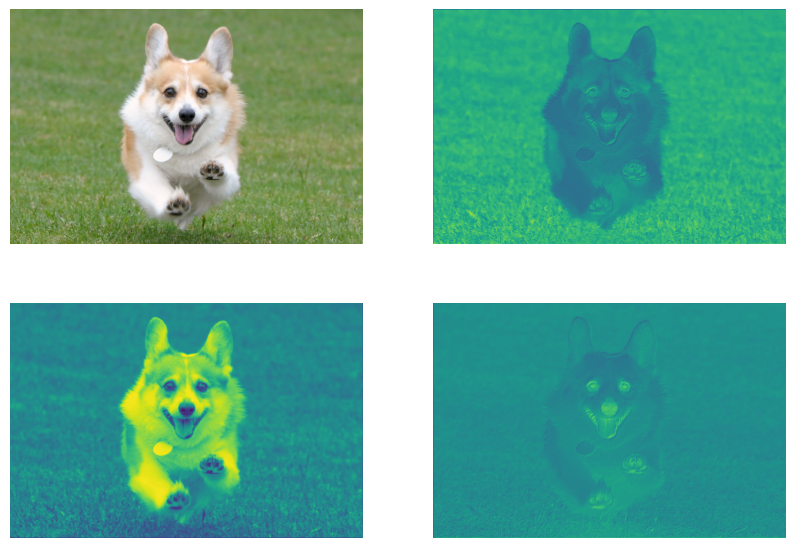

In [4]:
random_conv = myConvModel()
import numpy
import pylab
from PIL import Image
import numpy as np

# open random image of dimensions 639x516
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float64') / 256.#将PIL图像转换为NumPy数组，将像素值从[0, 255]缩放到大约[0, 1]范围，数组形状应为 (height, width, channels)。
img = np.expand_dims(img, axis=0)#使用 expand_dims 在第 0 维（即 batch 维度）增加一个维度，使形状变为 (1, height, width, channels)，以满足模型输入要求（模型期望输入包含batch维度）。

#上面相当于预处理
img_out = random_conv(img)


#通过一个随机初始化的卷积层（3个3×3卷积核）处理，然后分别显示原图以及卷积后得到的三个通道的特征图。
#由于卷积核是随机初始化的，输出的特征图会表现出不同的边缘或纹理响应，可以直观地看到卷积操作的效果。
pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img[0, :, :, :])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0])
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1])
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2])
pylab.show()
